In [ ]:
from __future__ import annotations

import copy
import random
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from torchvision import transforms as T
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Hyperparameters (Magic Numbers/Values)
SEED = 42
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
TRAIN_BACKBONE = True
IMAGE_SIZE = (224, 224)

PROJECT_ROOT = Path.cwd()
DRIVE_ROOT = PROJECT_ROOT / "drive" / "MyDrive" / "CV final project"
DATASET_ROOT = DRIVE_ROOT / "rwvc_bdd100k_balanced_300"
MANIFEST_PATH = DATASET_ROOT / "manifest.csv"
WANDB_PROJECT_BASE = "CV Project Training"
RUN_STAMP = datetime.now().strftime("%Y%m%d-%H%M%S")
WANDB_PROJECT = f"{WANDB_PROJECT_BASE} {RUN_STAMP}"
MODEL_DIR = DRIVE_ROOT / "models" / "efficientnet_b0_two_head"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ROAD_CLASSES = ["dry", "snow", "wet"]
VISIBILITY_CLASSES = ["good", "poor"]
COMBINED_CLASSES = [
    "dry / good",
    "dry / poor",
    "snow / good",
    "snow / poor",
    "wet / good",
    "wet / poor",
]
road_to_idx = {name: idx for idx, name in enumerate(ROAD_CLASSES)}
visibility_to_idx = {name: idx for idx, name in enumerate(VISIBILITY_CLASSES)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"W&B project: {WANDB_PROJECT}")





Device: cuda
Dataset root: /content/drive/MyDrive/CV final project/rwvc_bdd100k_balanced_300
W&B project: CV Project Training 20260501-022052


In [ ]:
# Fetch Splits from manifest file
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}. Run DataOps.ipynb first.")

manifest = pd.read_csv(MANIFEST_PATH).copy()
required_columns = {"split", "output_path", "road", "visibility"}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Manifest missing required columns: {sorted(missing_columns)}")

manifest["path"] = manifest["output_path"].map(lambda p: DATASET_ROOT / p)
missing_files = manifest.loc[~manifest["path"].map(Path.exists), ["split", "output_path"]]
if len(missing_files):
    display(missing_files.head())
    raise FileNotFoundError(f"{len(missing_files)} manifest image paths are missing")

print("Split sizes:")
display(manifest.groupby("split").size().rename("images").reset_index())

for split in ["train", "valid", "test"]:
    if split not in set(manifest["split"]):
        raise ValueError(f"Required split missing from manifest: {split}")


Split sizes:


,split,images
0,test,50
1,train,200
2,train_aug,136
3,train_synth,136
4,valid,50


In [ ]:
# add efficientnet-compatible transformations to the dataset
efficientnet_transform = T.Compose(
    [
        T.Resize(IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Data Loader

class RWVCBDD100KDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        labels = {
            "road": torch.tensor(road_to_idx[row["road"]], dtype=torch.long),
            "visibility": torch.tensor(visibility_to_idx[row["visibility"]], dtype=torch.long),
        }
        return image, labels


def make_split_dataset(split: str):
    frame = manifest.loc[manifest["split"] == split].copy()
    if frame.empty:
        raise ValueError(f"No rows found for split={split!r}")
    return RWVCBDD100KDataset(frame, transform=efficientnet_transform)


def make_loader(dataset: Dataset, shuffle: bool):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


In [ ]:
# Balance the baseline dataset in their augmented/synthesized versions
available_splits = set(manifest["split"])

training_corpuses = {
    "baseline_train": {"splits": ["train"], "balance_by_bucket": False},
    "train_plus_synth": {"splits": ["train", "train_synth"], "balance_by_bucket": False},
    "train_plus_aug": {"splits": ["train", "train_aug"], "balance_by_bucket": False},
    "train_plus_synth_plus_aug": {"splits": ["train", "train_synth", "train_aug"], "balance_by_bucket": True},
}

missing_by_corpus = {
    name: [split for split in spec["splits"] if split not in available_splits]
    for name, spec in training_corpuses.items()
}
missing_by_corpus = {name: splits for name, splits in missing_by_corpus.items() if splits}
if missing_by_corpus:
    raise ValueError(f"Generated training splits are missing. Run DataOps.ipynb first: {missing_by_corpus}")


def balance_frame_by_bucket(frame: pd.DataFrame):
    """Downsample every road/visibility bucket to the smallest bucket count."""
    bucket_counts = frame.groupby(["road", "visibility"]).size()
    target = int(bucket_counts.min())
    balanced_parts = []

    for (_, _), bucket_frame in frame.groupby(["road", "visibility"], sort=False):
        bucket_frame = bucket_frame.copy()
        if "source_split" in bucket_frame.columns:
            source_priority = {"train": 0, "train_augmented": 1, "synthesized": 2}
            bucket_frame["_source_priority"] = bucket_frame["source_split"].map(source_priority).fillna(1)
            bucket_frame = bucket_frame.sort_values(["_source_priority", "output_path"]).drop(columns=["_source_priority"])
        else:
            bucket_frame = bucket_frame.sort_values("output_path")
        balanced_parts.append(bucket_frame.head(target))

    return pd.concat(balanced_parts, ignore_index=True, sort=False)


def make_corpus_frame(splits: list[str], balance_by_bucket: bool = False):
    frame = manifest.loc[manifest["split"].isin(splits)].copy()
    if frame.empty:
        raise ValueError(f"No rows found for corpus splits: {splits}")
    if balance_by_bucket:
        frame = balance_frame_by_bucket(frame)
    return frame


def make_corpus_dataset(splits: list[str], balance_by_bucket: bool = False):
    frame = make_corpus_frame(splits, balance_by_bucket=balance_by_bucket)
    return RWVCBDD100KDataset(frame, transform=efficientnet_transform)


valid_dataset = make_split_dataset("valid")
test_dataset = make_split_dataset("test")
valid_loader = make_loader(valid_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)

for name, spec in training_corpuses.items():
    frame = make_corpus_frame(spec["splits"], balance_by_bucket=spec["balance_by_bucket"])
    print(
        f"{name}: splits={spec['splits']}, images={len(frame)}, "
        f"balance_by_bucket={spec['balance_by_bucket']}"
    )
    display(
        frame.groupby(["road", "visibility"])
        .size()
        .rename("images")
        .reset_index()
    )



baseline_train: splits=['train'], images=200, balance_by_bucket=False


,road,visibility,images
0,dry,good,35
1,dry,poor,21
2,snow,good,36
3,snow,poor,36
4,wet,good,36
5,wet,poor,36


train_plus_synth: splits=['train', 'train_synth'], images=336, balance_by_bucket=False


,road,visibility,images
0,dry,good,56
1,dry,poor,56
2,snow,good,56
3,snow,poor,56
4,wet,good,56
5,wet,poor,56


train_plus_aug: splits=['train', 'train_aug'], images=336, balance_by_bucket=False


,road,visibility,images
0,dry,good,56
1,dry,poor,56
2,snow,good,56
3,snow,poor,56
4,wet,good,56
5,wet,poor,56


train_plus_synth_plus_aug: splits=['train', 'train_synth', 'train_aug'], images=456, balance_by_bucket=True


,road,visibility,images
0,dry,good,76
1,dry,poor,76
2,snow,good,76
3,snow,poor,76
4,wet,good,76
5,wet,poor,76


In [ ]:
# Model
class EfficientNetB0TwoHead(nn.Module):
    def __init__(self, num_road_classes: int, num_visibility_classes: int, train_backbone: bool = True):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        for parameter in self.backbone.parameters():
            parameter.requires_grad = train_backbone

        self.road_head = nn.Linear(in_features, num_road_classes)
        self.visibility_head = nn.Linear(in_features, num_visibility_classes)

    def forward(self, x):
        features = self.backbone(x)
        return {
            "road": self.road_head(features),
            "visibility": self.visibility_head(features),
        }


def build_model():
    model = EfficientNetB0TwoHead(
        num_road_classes=len(ROAD_CLASSES),
        num_visibility_classes=len(VISIBILITY_CLASSES),
        train_backbone=TRAIN_BACKBONE,
    )
    return model.to(device)


criterion = nn.CrossEntropyLoss()


def compute_loss(outputs: dict, labels: dict):
    road_loss = criterion(outputs["road"], labels["road"])
    visibility_loss = criterion(outputs["visibility"], labels["visibility"])
    return road_loss + visibility_loss, road_loss, visibility_loss


In [ ]:
# training fn
def train_one_epoch(model, loader, optimizer):
    model.train()
    totals = {"loss": 0.0, "road_loss": 0.0, "visibility_loss": 0.0, "road_correct": 0, "visibility_correct": 0, "joint_score": 0.0, "exact_match_correct": 0, "n": 0}

    for images, labels in loader:
        images = images.to(device)
        labels = {key: value.to(device) for key, value in labels.items()}

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss, road_loss, visibility_loss = compute_loss(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        totals["loss"] += loss.item() * batch_size
        totals["road_loss"] += road_loss.item() * batch_size
        totals["visibility_loss"] += visibility_loss.item() * batch_size
        road_matches = outputs["road"].argmax(dim=1) == labels["road"]
        visibility_matches = outputs["visibility"].argmax(dim=1) == labels["visibility"]
        totals["road_correct"] += road_matches.sum().item()
        totals["visibility_correct"] += visibility_matches.sum().item()
        totals["joint_score"] += (0.5 * road_matches.float() + 0.5 * visibility_matches.float()).sum().item()
        totals["exact_match_correct"] += (road_matches & visibility_matches).sum().item()
        totals["n"] += batch_size

    return {
        "loss": totals["loss"] / totals["n"],
        "road_loss": totals["road_loss"] / totals["n"],
        "visibility_loss": totals["visibility_loss"] / totals["n"],
        "road_acc": totals["road_correct"] / totals["n"],
        "visibility_acc": totals["visibility_correct"] / totals["n"],
        "joint_score": totals["joint_score"] / totals["n"],
        "exact_match_acc": totals["exact_match_correct"] / totals["n"],
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    totals = {"loss": 0.0, "road_loss": 0.0, "visibility_loss": 0.0, "road_correct": 0, "visibility_correct": 0, "joint_score": 0.0, "exact_match_correct": 0, "n": 0}
    road_true, road_pred = [], []
    visibility_true, visibility_pred = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = {key: value.to(device) for key, value in labels.items()}
        outputs = model(images)
        loss, road_loss, visibility_loss = compute_loss(outputs, labels)

        road_predictions = outputs["road"].argmax(dim=1)
        visibility_predictions = outputs["visibility"].argmax(dim=1)

        batch_size = images.size(0)
        totals["loss"] += loss.item() * batch_size
        totals["road_loss"] += road_loss.item() * batch_size
        totals["visibility_loss"] += visibility_loss.item() * batch_size
        road_matches = road_predictions == labels["road"]
        visibility_matches = visibility_predictions == labels["visibility"]
        totals["road_correct"] += road_matches.sum().item()
        totals["visibility_correct"] += visibility_matches.sum().item()
        totals["joint_score"] += (0.5 * road_matches.float() + 0.5 * visibility_matches.float()).sum().item()
        totals["exact_match_correct"] += (road_matches & visibility_matches).sum().item()
        totals["n"] += batch_size

        road_true.extend(labels["road"].cpu().tolist())
        road_pred.extend(road_predictions.cpu().tolist())
        visibility_true.extend(labels["visibility"].cpu().tolist())
        visibility_pred.extend(visibility_predictions.cpu().tolist())

    metrics = {
        "loss": totals["loss"] / totals["n"],
        "road_loss": totals["road_loss"] / totals["n"],
        "visibility_loss": totals["visibility_loss"] / totals["n"],
        "road_acc": totals["road_correct"] / totals["n"],
        "visibility_acc": totals["visibility_correct"] / totals["n"],
        "joint_score": totals["joint_score"] / totals["n"],
        "exact_match_acc": totals["exact_match_correct"] / totals["n"],
    }
    predictions = {
        "road_true": road_true,
        "road_pred": road_pred,
        "visibility_true": visibility_true,
        "visibility_pred": visibility_pred,
    }
    return metrics, predictions



In [ ]:
# plot cm
def plot_confusion(y_true, y_pred, labels, title):
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    is_combined = len(labels) > 3
    fig, ax = plt.subplots(figsize=(7.5, 6.0) if is_combined else (5, 4))
    display_labels = [label.replace(" / ", "\n") for label in labels] if is_combined else labels
    display_obj = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=display_labels)
    display_obj.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    if is_combined:
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
    plt.tight_layout()
    return fig, matrix


def prefixed(prefix: str, metrics: dict):
    return {f"{prefix}/{key}": value for key, value in metrics.items()}


def encode_combined_labels(road_labels, visibility_labels):
    return [road * len(VISIBILITY_CLASSES) + visibility for road, visibility in zip(road_labels, visibility_labels)]




In [ ]:
# run full experiment
def run_experiment(corpus_name: str, spec: dict):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    splits = spec["splits"]
    balance_by_bucket = spec.get("balance_by_bucket", False)
    train_dataset = make_corpus_dataset(splits, balance_by_bucket=balance_by_bucket)
    train_loader = make_loader(train_dataset, shuffle=True)
    model = build_model()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    run = wandb.init(
        project=WANDB_PROJECT,
        name=corpus_name,
        config={
            "corpus_name": corpus_name,
            "train_splits": splits,
            "balance_by_bucket": balance_by_bucket,
            "train_size": len(train_dataset),
            "valid_size": len(valid_dataset),
            "test_size": len(test_dataset),
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "train_backbone": TRAIN_BACKBONE,
            "backbone": "torchvision.efficientnet_b0",
            "road_classes": ROAD_CLASSES,
            "visibility_classes": VISIBILITY_CLASSES,
        },
        reinit=True,
    )

    best_state = None
    best_epoch = None
    best_valid_exact_match_acc = float("-inf")
    best_valid_joint_score = float("-inf")
    best_valid_loss = float("inf")
    best_checkpoint_path = MODEL_DIR / f"{corpus_name}_best.pt"
    final_checkpoint_path = MODEL_DIR / f"{corpus_name}_final.pt"

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer)
        valid_metrics, _ = evaluate(model, valid_loader)

        is_better = (
            (valid_metrics["exact_match_acc"] > best_valid_exact_match_acc)
            or (
                valid_metrics["exact_match_acc"] == best_valid_exact_match_acc
                and valid_metrics["joint_score"] > best_valid_joint_score
            )
            or (
                valid_metrics["exact_match_acc"] == best_valid_exact_match_acc
                and valid_metrics["joint_score"] == best_valid_joint_score
                and valid_metrics["loss"] < best_valid_loss
            )
        )

        if is_better:
            best_epoch = epoch
            best_valid_exact_match_acc = valid_metrics["exact_match_acc"]
            best_valid_joint_score = valid_metrics["joint_score"]
            best_valid_loss = valid_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch,
                    "corpus_name": corpus_name,
                    "train_splits": splits,
                    "balance_by_bucket": balance_by_bucket,
                    "best_epoch": best_epoch,
                    "valid_exact_match_acc": best_valid_exact_match_acc,
                    "valid_joint_score": best_valid_joint_score,
                    "valid_loss": best_valid_loss,
                    "road_classes": ROAD_CLASSES,
                    "visibility_classes": VISIBILITY_CLASSES,
                    "config": dict(wandb.config),
                },
                best_checkpoint_path,
            )

        log_payload = {"epoch": epoch}
        log_payload.update(prefixed("train", train_metrics))
        log_payload.update(prefixed("valid", valid_metrics))
        wandb.log(log_payload)

        print(
            f"{corpus_name} epoch {epoch:02d}: "
            f"train_loss={train_metrics['loss']:.4f}, "
            f"valid_loss={valid_metrics['loss']:.4f}, "
            f"valid_road_acc={valid_metrics['road_acc']:.3f}, "
            f"valid_visibility_acc={valid_metrics['visibility_acc']:.3f}, "
            f"valid_joint_score={valid_metrics['joint_score']:.3f}, "
            f"valid_exact_match_acc={valid_metrics['exact_match_acc']:.3f}"
        )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": EPOCHS,
            "corpus_name": corpus_name,
            "train_splits": splits,
            "balance_by_bucket": balance_by_bucket,
            "road_classes": ROAD_CLASSES,
            "visibility_classes": VISIBILITY_CLASSES,
            "config": dict(wandb.config),
        },
        final_checkpoint_path,
    )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, test_predictions = evaluate(model, test_loader)
    wandb.log(prefixed("test", test_metrics))
    wandb.save(str(best_checkpoint_path))
    wandb.save(str(final_checkpoint_path))
    print(f"Saved best checkpoint: {best_checkpoint_path}")
    print(f"Saved final checkpoint: {final_checkpoint_path}")

    road_fig, road_cm = plot_confusion(
        test_predictions["road_true"],
        test_predictions["road_pred"],
        ROAD_CLASSES,
        f"{corpus_name}: road confusion matrix",
    )
    visibility_fig, visibility_cm = plot_confusion(
        test_predictions["visibility_true"],
        test_predictions["visibility_pred"],
        VISIBILITY_CLASSES,
        f"{corpus_name}: visibility confusion matrix",
    )
    combined_true = encode_combined_labels(
        test_predictions["road_true"],
        test_predictions["visibility_true"],
    )
    combined_pred = encode_combined_labels(
        test_predictions["road_pred"],
        test_predictions["visibility_pred"],
    )
    combined_fig, combined_cm = plot_confusion(
        combined_true,
        combined_pred,
        COMBINED_CLASSES,
        f"{corpus_name}: combined 6-class confusion matrix",
    )
    wandb.log(
        {
            "test/road_confusion_matrix": wandb.Image(road_fig),
            "test/visibility_confusion_matrix": wandb.Image(visibility_fig),
            "test/combined_confusion_matrix": wandb.Image(combined_fig),
        }
    )
    plt.show()

    run.summary.update(
        prefixed(
            "best_valid",
            {
                "epoch": best_epoch,
                "exact_match_acc": best_valid_exact_match_acc,
                "joint_score": best_valid_joint_score,
                "loss": best_valid_loss,
            },
        )
    )
    run.summary.update(prefixed("test", test_metrics))
    wandb.finish()

    return {
        "corpus_name": corpus_name,
        "train_splits": splits,
        "test_metrics": test_metrics,
        "road_confusion_matrix": road_cm,
        "visibility_confusion_matrix": visibility_cm,
        "combined_confusion_matrix": combined_cm,
        "best_checkpoint_path": best_checkpoint_path,
        "final_checkpoint_path": final_checkpoint_path,
    }






Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 366MB/s]
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: indro-umd (indro-umd-university-of-maryland) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


baseline_train epoch 01: train_loss=1.7630, valid_loss=1.6835, valid_road_acc=0.500, valid_visibility_acc=0.560, valid_joint_score=0.530, valid_exact_match_acc=0.220
baseline_train epoch 02: train_loss=1.4769, valid_loss=1.5530, valid_road_acc=0.600, valid_visibility_acc=0.660, valid_joint_score=0.630, valid_exact_match_acc=0.360
baseline_train epoch 03: train_loss=1.2838, valid_loss=1.4429, valid_road_acc=0.740, valid_visibility_acc=0.800, valid_joint_score=0.770, valid_exact_match_acc=0.600
baseline_train epoch 04: train_loss=1.0871, valid_loss=1.3277, valid_road_acc=0.720, valid_visibility_acc=0.720, valid_joint_score=0.720, valid_exact_match_acc=0.500
baseline_train epoch 05: train_loss=0.8543, valid_loss=1.2213, valid_road_acc=0.760, valid_visibility_acc=0.720, valid_joint_score=0.740, valid_exact_match_acc=0.540
baseline_train epoch 06: train_loss=0.7304, valid_loss=1.1246, valid_road_acc=0.780, valid_visibility_acc=0.720, valid_joint_score=0.750, valid_exact_match_acc=0.540
base

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Saved best checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/baseline_train_best.pt
Saved final checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/baseline_train_final.pt


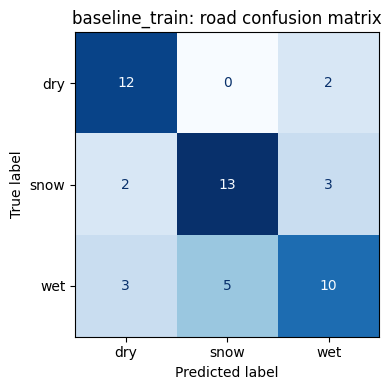

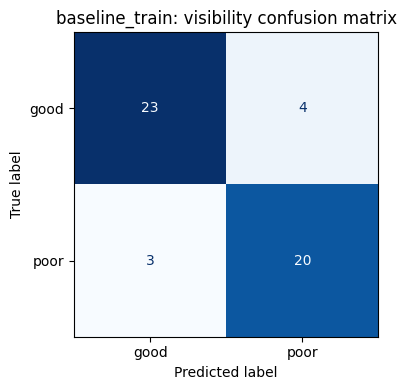

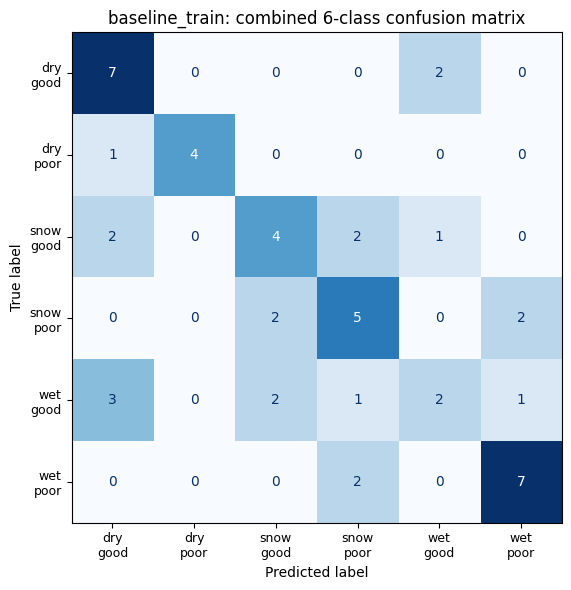

epoch,▁▂▃▃▄▅▆▆▇█
test/exact_match_acc,▁
test/joint_score,▁
test/loss,▁
test/road_acc,▁
test/road_loss,▁
test/visibility_acc,▁
test/visibility_loss,▁
train/exact_match_acc,▁▄▆▇▇▇████
train/joint_score,▁▅▆▇▇▇████
+12,...


train_plus_synth epoch 01: train_loss=1.6311, valid_loss=1.6375, valid_road_acc=0.580, valid_visibility_acc=0.620, valid_joint_score=0.600, valid_exact_match_acc=0.400
train_plus_synth epoch 02: train_loss=1.1934, valid_loss=1.4982, valid_road_acc=0.680, valid_visibility_acc=0.680, valid_joint_score=0.680, valid_exact_match_acc=0.460
train_plus_synth epoch 03: train_loss=0.9147, valid_loss=1.3501, valid_road_acc=0.700, valid_visibility_acc=0.760, valid_joint_score=0.730, valid_exact_match_acc=0.520
train_plus_synth epoch 04: train_loss=0.6972, valid_loss=1.1775, valid_road_acc=0.700, valid_visibility_acc=0.780, valid_joint_score=0.740, valid_exact_match_acc=0.540
train_plus_synth epoch 05: train_loss=0.5113, valid_loss=1.0949, valid_road_acc=0.780, valid_visibility_acc=0.780, valid_joint_score=0.780, valid_exact_match_acc=0.600
train_plus_synth epoch 06: train_loss=0.3472, valid_loss=1.0805, valid_road_acc=0.760, valid_visibility_acc=0.780, valid_joint_score=0.770, valid_exact_match_ac

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Saved best checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_synth_best.pt
Saved final checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_synth_final.pt


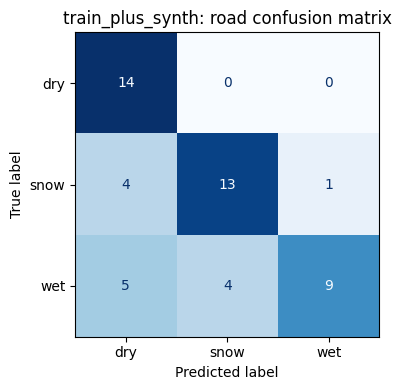

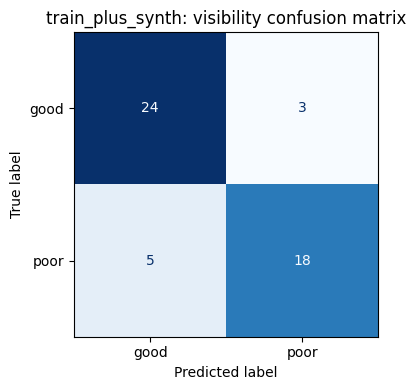

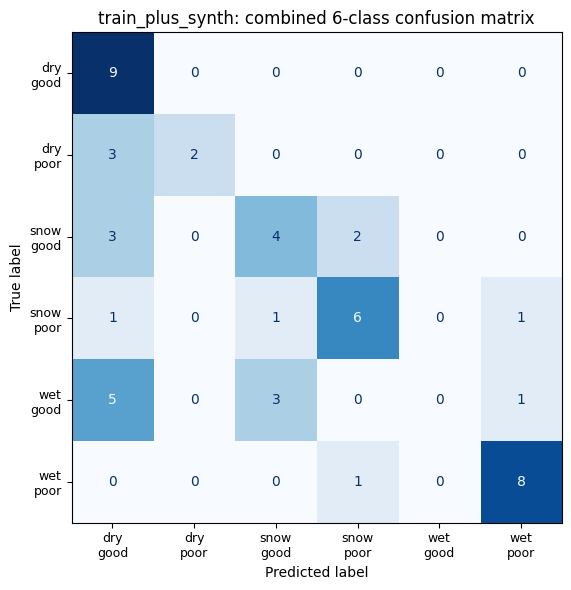

epoch,▁▂▃▃▄▅▆▆▇█
test/exact_match_acc,▁
test/joint_score,▁
test/loss,▁
test/road_acc,▁
test/road_loss,▁
test/visibility_acc,▁
test/visibility_loss,▁
train/exact_match_acc,▁▅▆▇▇▇████
train/joint_score,▁▅▆▇▇█████
+12,...


train_plus_aug epoch 01: train_loss=1.7133, valid_loss=1.6157, valid_road_acc=0.520, valid_visibility_acc=0.660, valid_joint_score=0.590, valid_exact_match_acc=0.300
train_plus_aug epoch 02: train_loss=1.3706, valid_loss=1.4570, valid_road_acc=0.660, valid_visibility_acc=0.740, valid_joint_score=0.700, valid_exact_match_acc=0.460
train_plus_aug epoch 03: train_loss=1.0522, valid_loss=1.2803, valid_road_acc=0.740, valid_visibility_acc=0.740, valid_joint_score=0.740, valid_exact_match_acc=0.540
train_plus_aug epoch 04: train_loss=0.7442, valid_loss=1.1325, valid_road_acc=0.760, valid_visibility_acc=0.780, valid_joint_score=0.770, valid_exact_match_acc=0.580
train_plus_aug epoch 05: train_loss=0.5222, valid_loss=1.0516, valid_road_acc=0.760, valid_visibility_acc=0.780, valid_joint_score=0.770, valid_exact_match_acc=0.580
train_plus_aug epoch 06: train_loss=0.3393, valid_loss=1.0282, valid_road_acc=0.720, valid_visibility_acc=0.780, valid_joint_score=0.750, valid_exact_match_acc=0.560
trai

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Saved best checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_aug_best.pt
Saved final checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_aug_final.pt


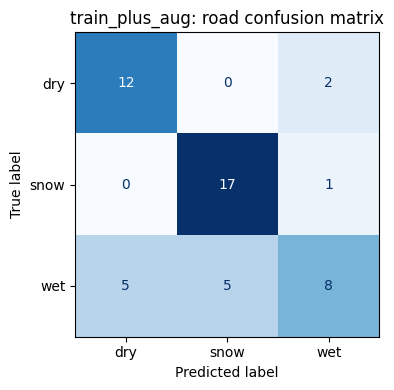

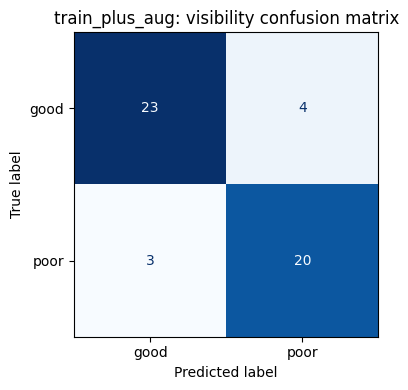

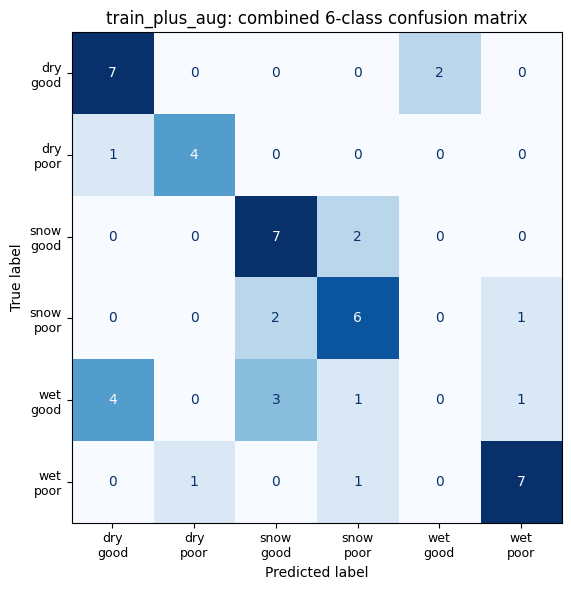

epoch,▁▂▃▃▄▅▆▆▇█
test/exact_match_acc,▁
test/joint_score,▁
test/loss,▁
test/road_acc,▁
test/road_loss,▁
test/visibility_acc,▁
test/visibility_loss,▁
train/exact_match_acc,▁▅▆▇▇█████
train/joint_score,▁▆▇▇▇█████
+12,...


train_plus_synth_plus_aug epoch 01: train_loss=1.6398, valid_loss=1.5604, valid_road_acc=0.620, valid_visibility_acc=0.660, valid_joint_score=0.640, valid_exact_match_acc=0.400
train_plus_synth_plus_aug epoch 02: train_loss=1.1622, valid_loss=1.3565, valid_road_acc=0.660, valid_visibility_acc=0.760, valid_joint_score=0.710, valid_exact_match_acc=0.480
train_plus_synth_plus_aug epoch 03: train_loss=0.7635, valid_loss=1.1502, valid_road_acc=0.740, valid_visibility_acc=0.800, valid_joint_score=0.770, valid_exact_match_acc=0.560
train_plus_synth_plus_aug epoch 04: train_loss=0.5197, valid_loss=1.0801, valid_road_acc=0.720, valid_visibility_acc=0.800, valid_joint_score=0.760, valid_exact_match_acc=0.560
train_plus_synth_plus_aug epoch 05: train_loss=0.3468, valid_loss=1.0529, valid_road_acc=0.800, valid_visibility_acc=0.800, valid_joint_score=0.800, valid_exact_match_acc=0.620
train_plus_synth_plus_aug epoch 06: train_loss=0.2246, valid_loss=1.0665, valid_road_acc=0.760, valid_visibility_ac

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Saved best checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_synth_plus_aug_best.pt
Saved final checkpoint: /content/drive/MyDrive/CV final project/models/efficientnet_b0_two_head/train_plus_synth_plus_aug_final.pt


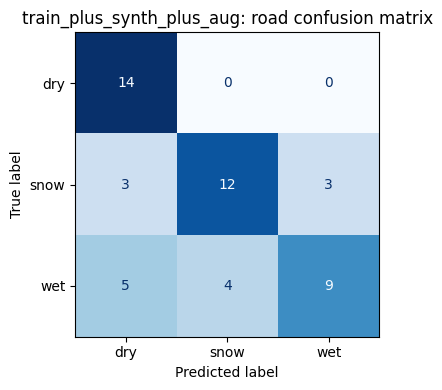

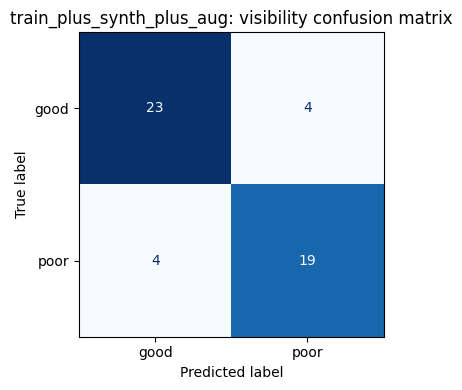

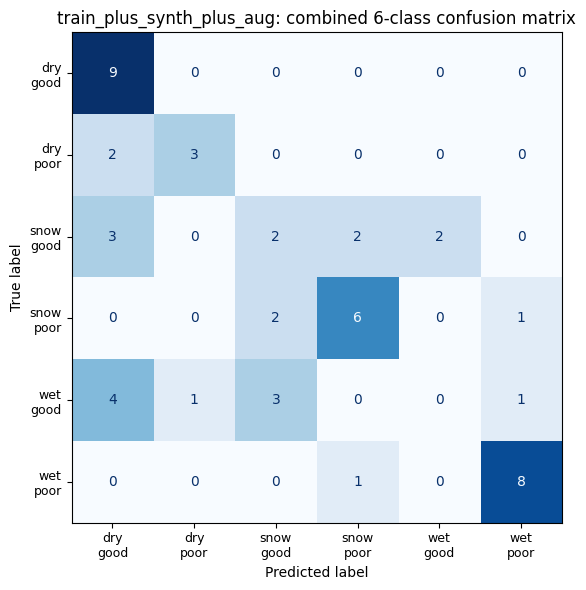

epoch,▁▂▃▃▄▅▆▆▇█
test/exact_match_acc,▁
test/joint_score,▁
test/loss,▁
test/road_acc,▁
test/road_loss,▁
test/visibility_acc,▁
test/visibility_loss,▁
train/exact_match_acc,▁▅▇▇▇█████
train/joint_score,▁▆▇▇▇█████
+12,...


,corpus_name,train_splits,best_checkpoint_path,final_checkpoint_path,loss,road_loss,visibility_loss,road_acc,visibility_acc,joint_score,exact_match_acc
0,baseline_train,train,/content/drive/MyDrive/CV final project/models...,/content/drive/MyDrive/CV final project/models...,1.087889,0.730659,0.357230,0.70,0.86,0.78,0.58
1,train_plus_synth,train+train_synth,/content/drive/MyDrive/CV final project/models...,/content/drive/MyDrive/CV final project/models...,1.019910,0.647868,0.372042,0.72,0.84,0.78,0.58
2,train_plus_aug,train+train_aug,/content/drive/MyDrive/CV final project/models...,/content/drive/MyDrive/CV final project/models...,1.066748,0.682422,0.384326,0.74,0.86,0.80,0.62
3,train_plus_synth_plus_aug,train+train_synth+train_aug,/content/drive/MyDrive/CV final project/models...,/content/drive/MyDrive/CV final project/models...,1.050961,0.661925,0.389036,0.70,0.84,0.77,0.56


In [ ]:
# display results
results = []
for corpus_name, spec in training_corpuses.items():
    results.append(run_experiment(corpus_name, spec))

summary_rows = []
for result in results:
    row = {
        "corpus_name": result["corpus_name"],
        "train_splits": "+".join(result["train_splits"]),
        "best_checkpoint_path": str(result["best_checkpoint_path"]),
        "final_checkpoint_path": str(result["final_checkpoint_path"]),
    }
    row.update(result["test_metrics"])
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
display(summary)


